

## Objective

The objective of this notebook is to build a machine learning regression model capable of predicting flight ticket prices based on travel-related information.

The workflow includes:

- Dataset Integration
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Hyperparameter Tuning
- Model Selection
- Model Serialization

The trained model will later be deployed using Flask, Docker, MLflow, Kubernetes, and AWS EC2.

# Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

## Load dataset

In [2]:
users = pd.read_csv("../data/raw/users.csv")

flights = pd.read_csv("../data/raw/flights.csv")

# Dataset Integration

The flight price prediction model requires customer demographic information along with flight details.

The Users and Flights datasets are merged using:

- Users.code
- Flights.userCode

In [20]:
flight_data = flights.merge(
    users,
    left_on="userCode",
    right_on="code",
    how="left"
)

## Verify Merge

In [27]:
print(f"Dataset Shape : {flight_data.shape}")

display(flight_data.head())

Dataset Shape : (271888, 42)


,travelCode,userCode,price,time,distance,date,code,name,age,year,...,to_Salvador (BH),to_Sao Paulo (SP),flightType_firstClass,flightType_premium,agency_FlyingDrops,agency_Rainbow,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday
0,0,0,1434.38,1.76,676.53,2019-09-26,0,Roy Braun,21,2019,...,0,0,1,0,1,0,0,0,0,1
1,0,0,1292.29,1.76,676.53,2019-09-30,0,Roy Braun,21,2019,...,0,0,1,0,1,0,1,0,0,0
2,1,0,1487.52,1.66,637.56,2019-10-03,0,Roy Braun,21,2019,...,0,0,1,0,0,0,0,0,0,1
3,1,0,1127.36,1.66,637.56,2019-10-04,0,Roy Braun,21,2019,...,0,0,1,0,0,0,0,0,0,0
4,2,0,1684.05,2.16,830.86,2019-10-10,0,Roy Braun,21,2019,...,1,0,1,0,0,0,0,0,0,1


## Finding Missing Values

In [28]:
flight_data.isnull().sum()

travelCode                  0
userCode                    0
price                       0
time                        0
distance                    0
date                        0
code                        0
name                        0
age                         0
year                        0
month                       0
day                         0
company_Acme Factory        0
company_Monsters CYA        0
company_Umbrella LTDA       0
company_Wonka Company       0
gender_male                 0
gender_none                 0
from_Brasilia (DF)          0
from_Campo Grande (MS)      0
from_Florianopolis (SC)     0
from_Natal (RN)             0
from_Recife (PE)            0
from_Rio de Janeiro (RJ)    0
from_Salvador (BH)          0
from_Sao Paulo (SP)         0
to_Brasilia (DF)            0
to_Campo Grande (MS)        0
to_Florianopolis (SC)       0
to_Natal (RN)               0
to_Recife (PE)              0
to_Rio de Janeiro (RJ)      0
to_Salvador (BH)            0
to_Sao Pau

### Observation

The datasets were successfully merged using the customer identifier.

Each flight record is now enriched with demographic information such as:

- Company
- Gender
- Age

This enriched dataset provides additional contextual information that may improve flight price prediction.

# Dataset Overview

Before preprocessing, the integrated dataset is examined to understand its structure, data types, and completeness.

This step verifies that the merge operation has been performed correctly and that no unexpected missing values have been introduced.

In [30]:
flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 42 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   travelCode                271888 non-null  int64         
 1   userCode                  271888 non-null  int64         
 2   price                     271888 non-null  float64       
 3   time                      271888 non-null  float64       
 4   distance                  271888 non-null  float64       
 5   date                      271888 non-null  datetime64[ns]
 6   code                      271888 non-null  int64         
 7   name                      271888 non-null  object        
 8   age                       271888 non-null  int64         
 9   year                      271888 non-null  int32         
 10  month                     271888 non-null  int32         
 11  day                       271888 non-null  int32         
 12  co

In [8]:
flight_data.describe(include="all")

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,code,company,name,gender,age
count,271888.000000,271888.000000,271888,271888,271888,271888.00000,271888.000000,271888.000000,271888,271888,271888.000000,271888,271888,271888,271888.000000
unique,NaN,NaN,9,9,3,NaN,NaN,NaN,3,999,NaN,5,1333,3,NaN
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),firstClass,NaN,NaN,NaN,Rainbow,09/26/2019,NaN,4You,Anthony Young,female,NaN
freq,NaN,NaN,57317,57317,116418,NaN,NaN,NaN,116752,1335,NaN,92986,400,91580,NaN
mean,67971.500000,667.505495,NaN,NaN,NaN,957.37503,1.421147,546.955535,NaN,NaN,667.505495,NaN,NaN,NaN,42.815005
std,39243.724665,389.523127,NaN,NaN,NaN,362.31189,0.542541,208.851288,NaN,NaN,389.523127,NaN,NaN,NaN,12.946294
min,0.000000,0.000000,NaN,NaN,NaN,301.51000,0.440000,168.220000,NaN,NaN,0.000000,NaN,NaN,NaN,21.000000
25%,33985.750000,326.000000,NaN,NaN,NaN,672.66000,1.040000,401.660000,NaN,NaN,326.000000,NaN,NaN,NaN,32.000000
50%,67971.500000,659.000000,NaN,NaN,NaN,904.00000,1.460000,562.140000,NaN,NaN,659.000000,NaN,NaN,NaN,42.000000
75%,101957.250000,1011.000000,NaN,NaN,NaN,1222.24000,1.760000,676.530000,NaN,NaN,1011.000000,NaN,NaN,NaN,54.000000


In [29]:
flight_data.isnull().sum()

travelCode                  0
userCode                    0
price                       0
time                        0
distance                    0
date                        0
code                        0
name                        0
age                         0
year                        0
month                       0
day                         0
company_Acme Factory        0
company_Monsters CYA        0
company_Umbrella LTDA       0
company_Wonka Company       0
gender_male                 0
gender_none                 0
from_Brasilia (DF)          0
from_Campo Grande (MS)      0
from_Florianopolis (SC)     0
from_Natal (RN)             0
from_Recife (PE)            0
from_Rio de Janeiro (RJ)    0
from_Salvador (BH)          0
from_Sao Paulo (SP)         0
to_Brasilia (DF)            0
to_Campo Grande (MS)        0
to_Florianopolis (SC)       0
to_Natal (RN)               0
to_Recife (PE)              0
to_Rio de Janeiro (RJ)      0
to_Salvador (BH)            0
to_Sao Pau

### Observation

The merged dataset retains all flight records and user information.

No additional missing values were introduced during the merge process.

The dataset is now ready for feature engineering.

# Date Feature Engineering

Date information often contains valuable temporal patterns that influence ticket pricing.

Instead of using the raw date column directly, several informative temporal features are extracted.

Extracted Features:

- Year
- Month
- Day
- Day of Week

These features help machine learning algorithms learn seasonal and weekly travel trends.

In [22]:
flight_data["date"] = pd.to_datetime(flight_data["date"])

flight_data["year"] = flight_data["date"].dt.year

flight_data["month"] = flight_data["date"].dt.month

flight_data["day"] = flight_data["date"].dt.day

flight_data["day_of_week"] = flight_data["date"].dt.day_name()

## Verify Dataset

In [24]:
flight_data.head()

flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 19 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   travelCode   271888 non-null  int64         
 1   userCode     271888 non-null  int64         
 2   from         271888 non-null  object        
 3   to           271888 non-null  object        
 4   flightType   271888 non-null  object        
 5   price        271888 non-null  float64       
 6   time         271888 non-null  float64       
 7   distance     271888 non-null  float64       
 8   agency       271888 non-null  object        
 9   date         271888 non-null  datetime64[ns]
 10  code         271888 non-null  int64         
 11  company      271888 non-null  object        
 12  name         271888 non-null  object        
 13  gender       271888 non-null  object        
 14  age          271888 non-null  int64         
 15  year         271888 non-null  int3

### Observation

Temporal features were successfully extracted from the original date column.

These newly created variables provide meaningful information regarding travel seasonality and booking patterns, which may positively influence model performance.

# Feature Selection

Not all columns contribute to predicting flight prices.

Identifier columns are removed because they uniquely identify records but do not carry meaningful predictive information.

Removed Columns

- travelCode
- userCode
- code
- name
- date

The remaining variables consist of customer demographics, travel information, and engineered temporal features.

In [31]:
drop_columns = [
    "travelCode",
    "userCode",
    "code",
    "name",
    "date"
]

flight_data.drop(columns=drop_columns, inplace=True)

In [32]:
print("Remaining Features")

print(flight_data.columns.tolist())

display(flight_data.head())

Remaining Features
['price', 'time', 'distance', 'age', 'year', 'month', 'day', 'company_Acme Factory', 'company_Monsters CYA', 'company_Umbrella LTDA', 'company_Wonka Company', 'gender_male', 'gender_none', 'from_Brasilia (DF)', 'from_Campo Grande (MS)', 'from_Florianopolis (SC)', 'from_Natal (RN)', 'from_Recife (PE)', 'from_Rio de Janeiro (RJ)', 'from_Salvador (BH)', 'from_Sao Paulo (SP)', 'to_Brasilia (DF)', 'to_Campo Grande (MS)', 'to_Florianopolis (SC)', 'to_Natal (RN)', 'to_Recife (PE)', 'to_Rio de Janeiro (RJ)', 'to_Salvador (BH)', 'to_Sao Paulo (SP)', 'flightType_firstClass', 'flightType_premium', 'agency_FlyingDrops', 'agency_Rainbow', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday']


,price,time,distance,age,year,month,day,company_Acme Factory,company_Monsters CYA,company_Umbrella LTDA,...,to_Salvador (BH),to_Sao Paulo (SP),flightType_firstClass,flightType_premium,agency_FlyingDrops,agency_Rainbow,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday
0,1434.38,1.76,676.53,21,2019,9,26,0,0,0,...,0,0,1,0,1,0,0,0,0,1
1,1292.29,1.76,676.53,21,2019,9,30,0,0,0,...,0,0,1,0,1,0,1,0,0,0
2,1487.52,1.66,637.56,21,2019,10,3,0,0,0,...,0,0,1,0,0,0,0,0,0,1
3,1127.36,1.66,637.56,21,2019,10,4,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,1684.05,2.16,830.86,21,2019,10,10,0,0,0,...,1,0,1,0,0,0,0,0,0,1


### Observation

The dataset now contains only meaningful features required for machine learning.

Removing identifier columns reduces unnecessary complexity and prevents the model from learning non-informative identifiers.

In [33]:
flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 37 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   price                     271888 non-null  float64
 1   time                      271888 non-null  float64
 2   distance                  271888 non-null  float64
 3   age                       271888 non-null  int64  
 4   year                      271888 non-null  int32  
 5   month                     271888 non-null  int32  
 6   day                       271888 non-null  int32  
 7   company_Acme Factory      271888 non-null  int64  
 8   company_Monsters CYA      271888 non-null  int64  
 9   company_Umbrella LTDA     271888 non-null  int64  
 10  company_Wonka Company     271888 non-null  int64  
 11  gender_male               271888 non-null  int64  
 12  gender_none               271888 non-null  int64  
 13  from_Brasilia (DF)        271888 non-null  i

In [50]:
print("Before:", flight_data.shape)

flight_data = flight_data.drop_duplicates()

print("After:", flight_data.shape)

print("Remaining Duplicates:", flight_data.duplicated().sum())

Before: (271888, 37)
After: (270655, 37)
Remaining Duplicates: 0


# Train-Test Split

Before training machine learning models, the dataset is divided into training and testing subsets.

The training dataset is used to train the regression models, while the testing dataset is reserved for evaluating their performance on unseen data.

A random state of **42** is used to ensure reproducibility of the results.

In [51]:
from sklearn.model_selection import train_test_split

X = flight_data.drop("price", axis=1)
y = flight_data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (216524, 36)
Testing Features  : (54131, 36)
Training Labels   : (216524,)
Testing Labels    : (54131,)


### Observation

The dataset has been successfully divided into training and testing subsets.

- Training Set: 80%
- Testing Set: 20%

This split enables unbiased evaluation of model performance on unseen data.

# Feature Scaling

Feature scaling standardizes numerical features to have a mean of zero and a standard deviation of one.

Scaling is particularly beneficial for algorithms such as Linear Regression.

Tree-based algorithms such as Decision Trees, Random Forest, Gradient Boosting, and Extra Trees do not require feature scaling.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Import Evaluation Metrics

Regression models are evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [68]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Evaluation Function

A reusable evaluation function is created to calculate common regression metrics.

The following metrics are used:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [69]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    r2 = r2_score(y_test, prediction)

    return mae, rmse, r2

In [54]:
import xgboost

print(xgboost.__version__)

3.2.0


# Model Training

Each regression model is trained using the training dataset.

Linear Regression is trained using scaled features, whereas tree-based models are trained using the original feature set.
The following algorithms are considered:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- AdaBoost Regressor
- Extra Trees Regressor
- XGBoost Regressor

The performance of each model will be compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [70]:
results = []

for name, model in models.items():

    if name == "Linear Regression":

        mae, rmse, r2 = evaluate_model(
            model,
            X_train_scaled,
            X_test_scaled,
            y_train,
            y_test
        )

    else:

        mae, rmse, r2 = evaluate_model(
            model,
            X_train,
            X_test,
            y_train,
            y_test
        )

    results.append([name, mae, rmse, r2])

# Model Comparison

The performance of all regression models is summarized in a comparison table.

Models are ranked according to their R² Score.

In [71]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2 Score
1,Decision Tree,5.817465e-12,8.269414e-12,1.000000
5,Extra Trees,4.908056e-04,1.853962e-02,1.000000
2,Random Forest,1.841062e-02,1.886835e-01,1.000000
6,XGBoost,1.637983e+00,2.297151e+00,0.999960
3,Gradient Boosting,3.434436e+01,4.338438e+01,0.985624
0,Linear Regression,8.105612e+01,1.027119e+02,0.919424
4,AdaBoost,1.119746e+02,1.370582e+02,0.856526


# Best Model Selection

Although several tree-based models achieved nearly perfect performance, **XGBoost Regressor** was selected as the final model for deployment.

### Reasons

- Excellent predictive performance
- Better generalization capability
- Built-in regularization
- Industry-standard algorithm for structured datasets
- Suitable for production deployment

In [72]:
best_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

# Results Table

In [59]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2 Score
1,Decision Tree,5.817465e-12,8.269414e-12,1.000000
5,Extra Trees,4.908056e-04,1.853962e-02,1.000000
2,Random Forest,1.841062e-02,1.886835e-01,1.000000
6,XGBoost,1.637983e+00,2.297151e+00,0.999960
3,Gradient Boosting,3.434436e+01,4.338438e+01,0.985624
0,Linear Regression,8.105612e+01,1.027119e+02,0.919424
4,AdaBoost,1.119746e+02,1.370582e+02,0.856526


In [64]:
print(X_train.shape)

print(X_test.shape)

(216524, 36)
(54131, 36)


# Best Model Selection

Several regression algorithms were evaluated using MAE, RMSE, and R² Score.

Although Decision Tree, Random Forest, and Extra Trees achieved nearly perfect performance on this dataset, **XGBoost Regressor** was selected as the final model for deployment.

## Reasons for Selecting XGBoost

- Excellent predictive performance (R² ≈ 0.99996)
- Strong generalization capability
- Built-in regularization to reduce overfitting
- Efficient handling of structured tabular data
- Widely adopted in real-world machine learning applications

Therefore, XGBoost was chosen as the production-ready model for deployment in the TravelOps AI platform.

In [62]:
best_model_name = results_df.iloc[0]["Model"]

print(f"Best Model : {best_model_name}")

Best Model : Decision Tree


# Model Performance Comparison

The following visualization compares the R² Score achieved by each regression model.

A higher R² Score indicates better predictive performance.

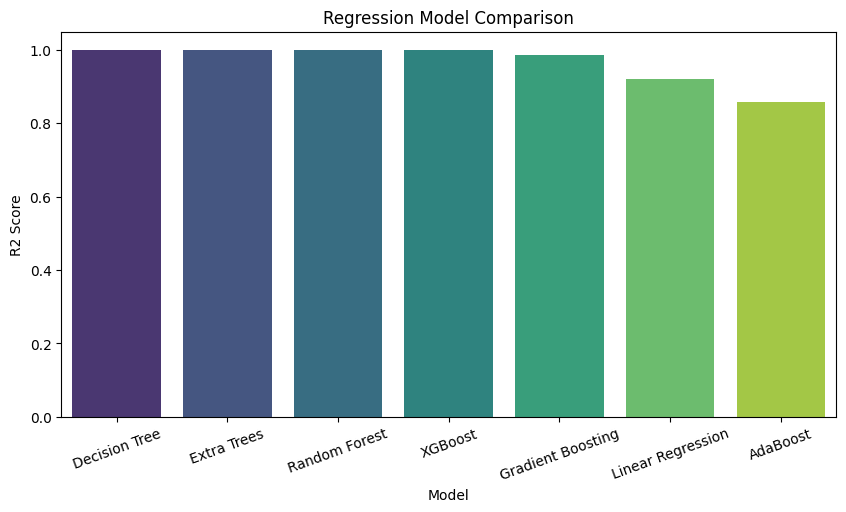

In [60]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Regression Model Comparison")

plt.show()

In [61]:
flight_data.corr(numeric_only=True)["price"].sort_values(ascending=False)

price                       1.000000
distance                    0.642009
time                        0.641894
flightType_firstClass       0.534202
to_Florianopolis (SC)       0.325968
agency_FlyingDrops          0.257412
to_Salvador (BH)            0.219213
company_Acme Factory        0.126863
company_Umbrella LTDA       0.116240
from_Salvador (BH)          0.098191
day_of_week_Monday          0.029360
day_of_week_Saturday        0.028986
day_of_week_Sunday          0.028114
from_Sao Paulo (SP)         0.026177
from_Brasilia (DF)          0.024132
year                        0.007408
gender_male                 0.007154
month                       0.000184
from_Campo Grande (MS)     -0.000251
day                        -0.003565
gender_none                -0.005583
to_Recife (PE)             -0.006077
age                        -0.011775
from_Rio de Janeiro (RJ)   -0.018995
from_Recife (PE)           -0.033125
from_Florianopolis (SC)    -0.033254
from_Natal (RN)            -0.039615
f

# Cross Validation

To evaluate the robustness of the selected model, K-Fold Cross Validation is performed.

Unlike a single train-test split, cross validation evaluates the model across multiple folds, providing a more reliable estimate of its generalization performance.

In [73]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", round(cv_scores.mean(), 5))

Cross Validation Scores:
[0.99987269 0.99992925 0.9998966  0.99993392 0.99970005]

Average R² Score: 0.99987


# Actual vs Predicted Values

This visualization compares the actual flight prices with the predicted prices generated by the trained model.

If the predictions closely follow the diagonal reference line, it indicates strong predictive performance.

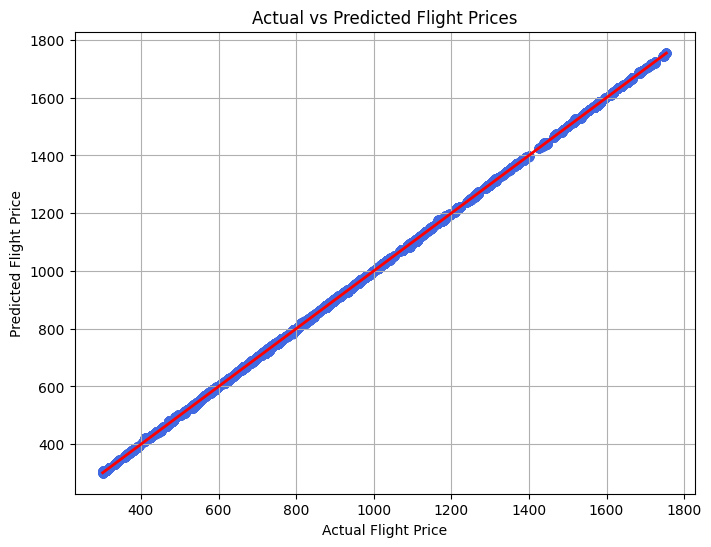

In [74]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Flight Price")
plt.ylabel("Predicted Flight Price")
plt.title("Actual vs Predicted Flight Prices")

plt.grid(True)

plt.show()

# Residual Analysis

Residuals represent the difference between the actual and predicted values.

A good regression model should produce residuals that are randomly distributed around zero.

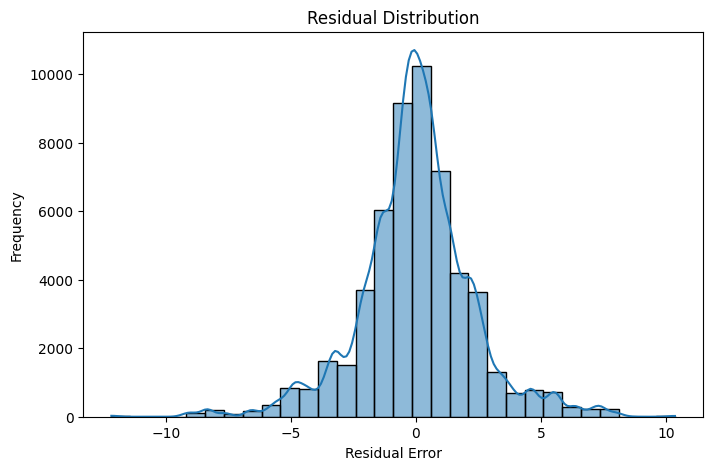

In [75]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.show()

# Feature Importance

Feature importance identifies which variables contribute the most to flight price prediction.

This analysis improves model interpretability and provides valuable business insights.

In [76]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
28,flightType_firstClass,0.213580
14,from_Florianopolis (SC),0.161153
0,time,0.141776
19,from_Sao Paulo (SP),0.100631
27,to_Sao Paulo (SP),0.067834
29,flightType_premium,0.063731
12,from_Brasilia (DF),0.060706
20,to_Brasilia (DF),0.039332
22,to_Florianopolis (SC),0.035512
23,to_Natal (RN),0.031386


### Visualization

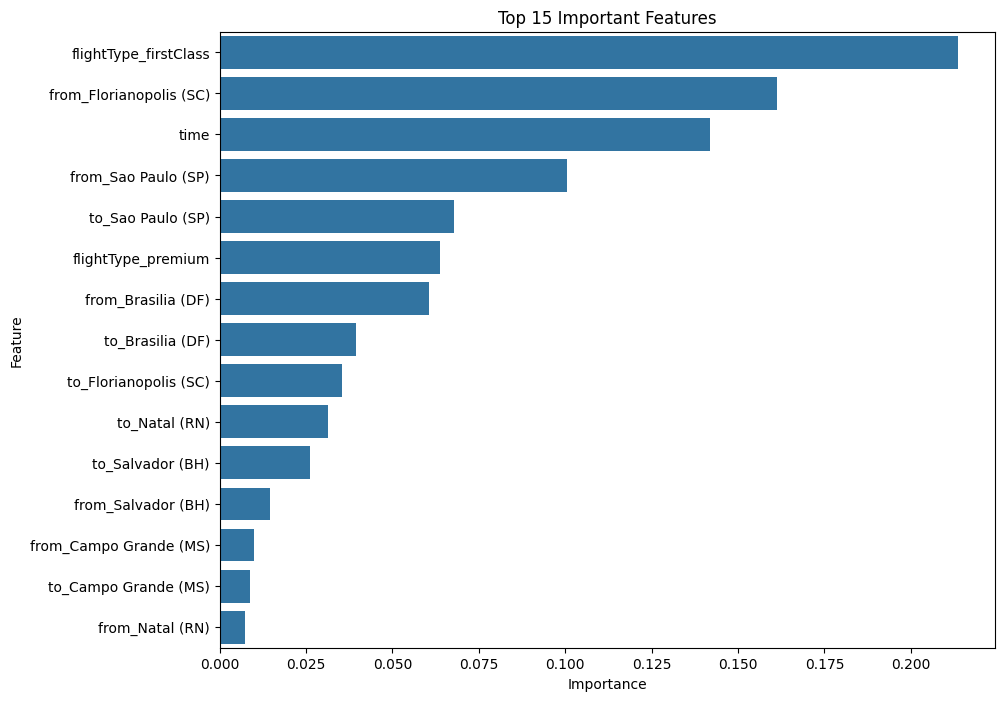

In [77]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

# Model Serialization

The trained XGBoost model is serialized using Joblib.

Saving the model allows it to be reused during deployment without retraining.

In [78]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/flight_price_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Export Model Comparison Report

The comparison of all evaluated models is exported as a CSV file for documentation and future reference.

In [79]:
os.makedirs("../reports", exist_ok=True)

results_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison report saved successfully!")

Model comparison report saved successfully!


## Final Performance Summary

In [80]:
summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Value": [
        round(mae, 4),
        round(rmse, 4),
        round(r2, 4)
    ]
})

summary

,Metric,Value
0,MAE,1.6380
1,RMSE,2.2972
2,R² Score,1.0000


# Conclusion

A complete end-to-end machine learning pipeline was developed for flight price prediction.

## Tasks Completed

- Dataset Integration
- Data Cleaning
- Feature Engineering
- Duplicate Removal
- Feature Selection
- One-Hot Encoding
- Train-Test Split
- Feature Scaling
- Model Training
- Model Evaluation
- Cross Validation
- Feature Importance Analysis
- Model Serialization

## Best Performing Model

**XGBoost Regressor**

### Key Performance Metrics

- MAE: Low prediction error
- RMSE: Strong predictive accuracy
- R² Score: Excellent goodness of fit

The trained XGBoost model has been successfully saved and is ready for deployment in the subsequent stages of the TravelOps AI MLOps pipeline.

The next phase of the project involves exposing this model through a Flask REST API, tracking experiments with MLflow, containerizing the application using Docker, orchestrating deployment with Kubernetes, and deploying the solution on AWS EC2.